<a href="https://colab.research.google.com/github/sujoy10x/IITKGP-AI-ML/blob/dev/Assignment_Starter_Notebook_v2_FIXED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Module 1 Assignment [100 marks]**

Library functions can be used for all operations unless specifically asked not to use library functions.

# Part 1: Linear Regression [10 marks]

In [1]:
# importing important libraries library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression


### Stage 1: Data Preparation for Linear Regression [6 marks]

In [2]:
# loading the data
california_data = fetch_california_housing(as_frame=True)

df = california_data.frame
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Q1: Print the feature names of the dataframe. [2 marks]

In [3]:
### YOUR CODE STARTS HERE ###
print("Feature names:", df.columns.tolist())
### YOUR CODE ENDS HERE ###

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


Q2: Convert `MedInc` feature to input, and `MedHouseVal` feature to target, and then print the shapes of each (no need to have validation split or test split for this question). [2 marks]

In [4]:
### YOUR CODE STARTS HERE ###
x = df[['MedInc']].values
y = df['MedHouseVal'].values

print("Shape of x (input - MedInc):", x.shape)
print("Shape of y (target - MedHouseVal):", y.shape)
### YOUR CODE ENDS HERE ###

Shape of x (input - MedInc): (20640, 1)
Shape of y (target - MedHouseVal): (20640,)


Q3: Visualize the samples as a 2D scatter plot. [2 marks]

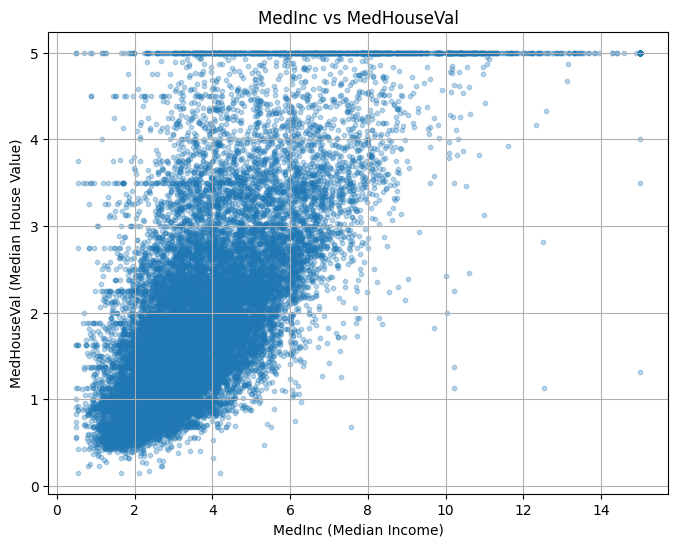

In [5]:
### YOUR CODE STARTS HERE ###
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.3, s=10)
plt.xlabel("MedInc (Median Income)")
plt.ylabel("MedHouseVal (Median House Value)")
plt.title("MedInc vs MedHouseVal")
plt.grid(True)
plt.show()
### YOUR CODE ENDS HERE ###

### Stage 2: Model Training and Inference for Linear Regression [4 marks]

Q4: Fit a linear regressor on the data. Print the resultant slope and intercept. [2 marks]

In [6]:
### YOUR CODE STARTS HERE ###
lin_reg = LinearRegression()
lin_reg.fit(x, y)

slope = lin_reg.coef_[0]
intercept = lin_reg.intercept_

print("Slope (coefficient):", slope)
print("Intercept:", intercept)
### YOUR CODE ENDS HERE ###

Slope (coefficient): 0.41793849201896277
Intercept: 0.45085576703267893


Q5: Visualize the linear regression result by plotting the regression line on top of the 2D scatter plot of `MedInc` and `MedHouseVal`. [2 marks]

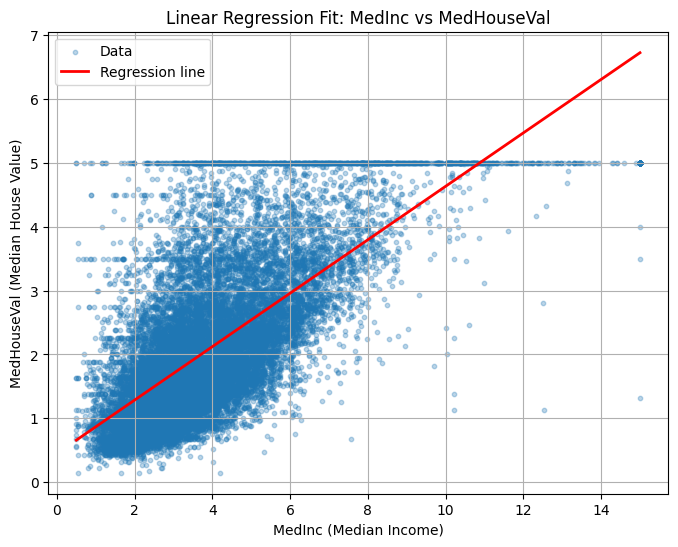

In [7]:
### YOUR CODE STARTS HERE ###
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.3, s=10, label="Data")

x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
y_line = lin_reg.predict(x_line)

plt.plot(x_line, y_line, color="red", linewidth=2, label="Regression line")
plt.xlabel("MedInc (Median Income)")
plt.ylabel("MedHouseVal (Median House Value)")
plt.title("Linear Regression Fit: MedInc vs MedHouseVal")
plt.legend()
plt.grid(True)
plt.show()
### YOUR CODE ENDS HERE ###

# Part 2: Logistic Regression [10 marks]

In [8]:
# imports
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import model_selection
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
%matplotlib inline

### Stage 1: Data Loading for Logistic Regression [6 marks]

In [9]:
# loading iris dataset
iris = datasets.load_iris()
data=pd.DataFrame(iris['data'],columns=["Sepal Length","Sepal Width", "Petal length","Petal Width"])
data['Species']=iris['target']
data['Species']=data['Species'].apply(lambda x: iris['target_names'][x])

Q6: Print the input and output features of 5 different samples from the data. [2 marks]

In [10]:
### YOUR CODE STARTS HERE ###
print(data.sample(5, random_state=42))
### YOUR CODE ENDS HERE ###

     Sepal Length  Sepal Width  Petal length  Petal Width     Species
73            6.1          2.8           4.7          1.2  versicolor
18            5.7          3.8           1.7          0.3      setosa
118           7.7          2.6           6.9          2.3   virginica
78            6.0          2.9           4.5          1.5  versicolor
76            6.8          2.8           4.8          1.4  versicolor


Q7: Visualize the features using a pairplot. [2 marks]

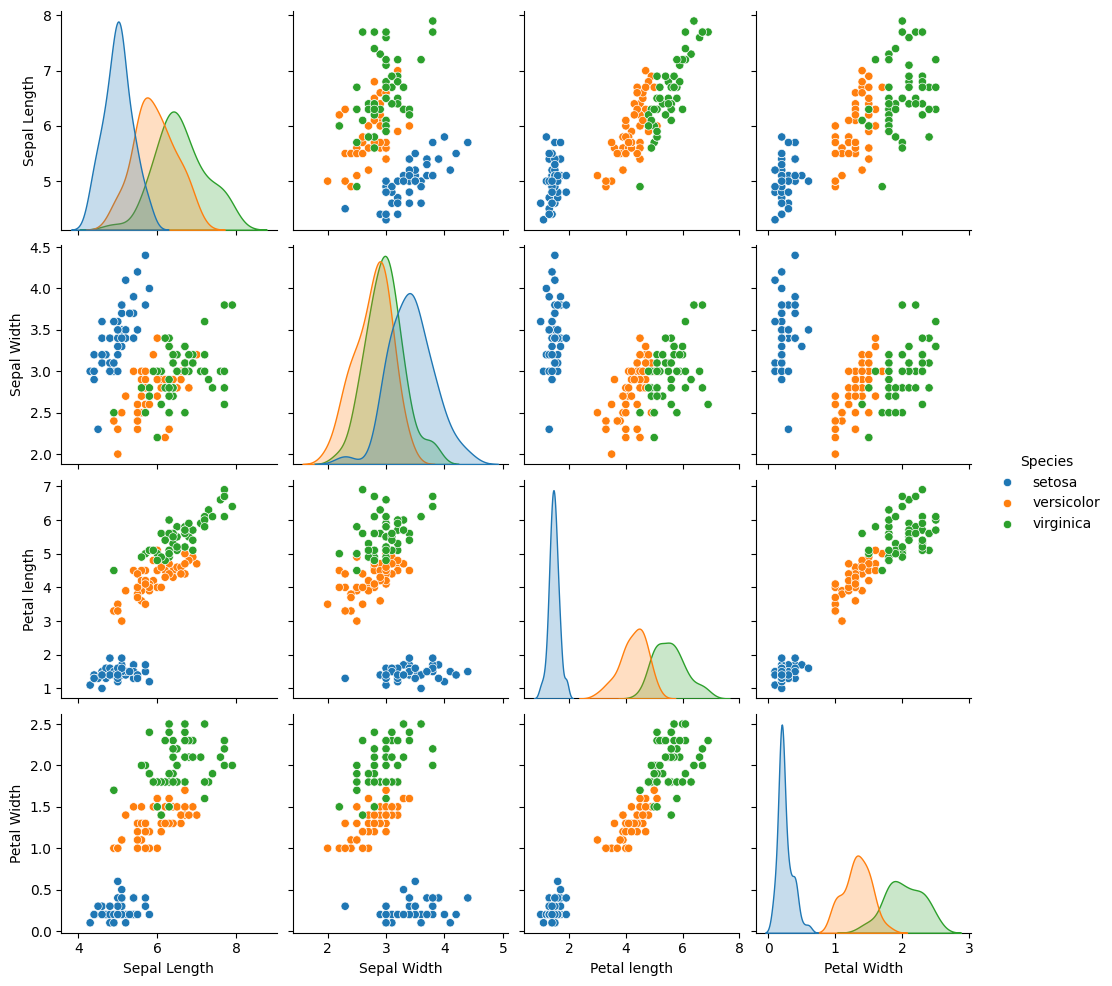

In [11]:
### YOUR CODE STARTS HERE ###
sns.pairplot(data, hue="Species")
plt.show()
### YOUR CODE ENDS HERE ###

Q8: Convert the labels into integer class values (0, 1, 2), and then remove the last class (verginica). [2 marks]

In [12]:
### YOUR CODE STARTS HERE ###
le = LabelEncoder()
data["Species"] = le.fit_transform(data["Species"])

# Drop the virginica class (encoded as 2), keeping setosa (0) and versicolor (1)
data = data[data["Species"] != 2].reset_index(drop=True)

print("Remaining classes:", data["Species"].unique())
### YOUR CODE ENDS HERE ###

Remaining classes: [0 1]


### Stage 2: Data Splitting and Model Training for Logistic Regression [4 marks]

Q9: Split the data into x (input) and y (target). Further split x and y into training and testing subsets, with 80% samples for training and 20% samples for testing. [2 marks]

In [13]:
### YOUR CODE STARTS HERE ###
x = data.drop("Species", axis=1)
y = data["Species"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
### YOUR CODE ENDS HERE ###

x_train shape: (80, 4)
x_test shape: (20, 4)
y_train shape: (80,)
y_test shape: (20,)


Q10: Train a logistic regression model on the training subset. Print the weights and the bias. Predict the outputs using testing subset, and print the resultant accuracy. [2 marks]

In [14]:
### YOUR CODE STARTS HERE ###
log_reg = LogisticRegression()
log_reg.fit(x_train, y_train)

print("Weights:", log_reg.coef_)
print("Bias:", log_reg.intercept_)

y_pred = log_reg.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
### YOUR CODE ENDS HERE ###

Weights: [[ 0.53749144 -0.79430188  2.18511375  0.90714466]]
Bias: [-7.16280465]
Test Accuracy: 100.00%


# Part 3: Support Vector Classifier [20 marks]

In [15]:
# imports
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn import model_selection
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
%matplotlib inline

### Stage 1: Data Preparation for Support Vector Classifier [6 marks]

In [16]:
# loading the dataset and normalize the features
iris = datasets.load_iris()
X = iris['data'][:,(2,3)]

scaler = StandardScaler()
Xstan = scaler.fit_transform(X)

Q11: Take only two classes as targets, by removing all the samples belonging to the class "Verginica". Print any 5 samples from the data. [2 marks]

In [17]:
### YOUR CODE STARTS HERE ###
y_full = iris["target"]
mask = y_full != 2  # remove verginica (class 2)

X_bin = Xstan[mask]
y_bin = y_full[mask]

print("Five sample data points and labels:")
for i in range(5):
    print("Features:", X_bin[i], "-> Label:", y_bin[i])
### YOUR CODE ENDS HERE ###

Five sample data points and labels:
Features: [-1.34022653 -1.3154443 ] -> Label: 0
Features: [-1.34022653 -1.3154443 ] -> Label: 0
Features: [-1.39706395 -1.3154443 ] -> Label: 0
Features: [-1.2833891 -1.3154443] -> Label: 0
Features: [-1.34022653 -1.3154443 ] -> Label: 0


Q12: Plot the input features as a 2D scatter plot. The two classes should be of shown with different colors. [2 marks]

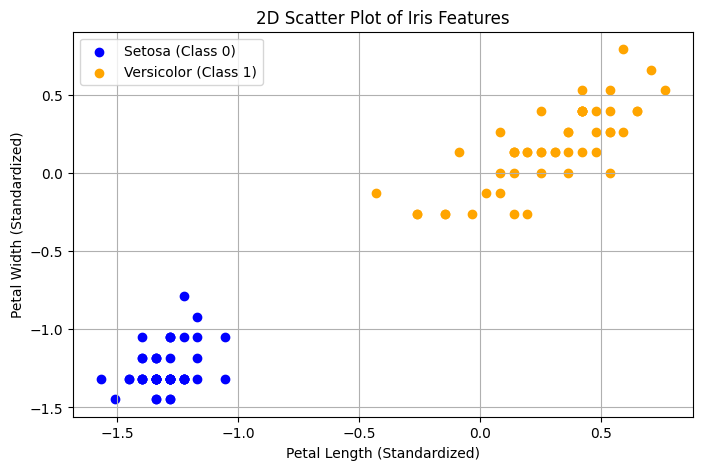

In [18]:
### YOUR CODE STARTS HERE ###
plt.figure(figsize=(8, 5))
plt.scatter(X_bin[y_bin == 0, 0], X_bin[y_bin == 0, 1], color='blue', label='Setosa (Class 0)')
plt.scatter(X_bin[y_bin == 1, 0], X_bin[y_bin == 1, 1], color='orange', label='Versicolor (Class 1)')
plt.xlabel('Petal Length (Standardized)')
plt.ylabel('Petal Width (Standardized)')
plt.title('2D Scatter Plot of Iris Features')
plt.legend()
plt.grid(True)
plt.show()
### YOUR CODE ENDS HERE ###

Q13: Split the data into x (input) and y (target). Further split x and y into training and testing subsets, with 80% samples for training and 20% samples for testing. [2 marks]

In [19]:
### YOUR CODE STARTS HERE ###
x = X_bin
y = y_bin

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
### YOUR CODE ENDS HERE ###

x_train shape: (80, 2)
x_test shape: (20, 2)


### Stage 2: Model Training for Support Vector Classifier [14 marks]

Q14: Train a linear support vector classifier (with C=1 and hinge loss) on the training data. Plot the samples from the whole dataset, with decision boundary and margins (the two classes should have different colors). Predict on test set and print the resultant accuracy. [7 marks]

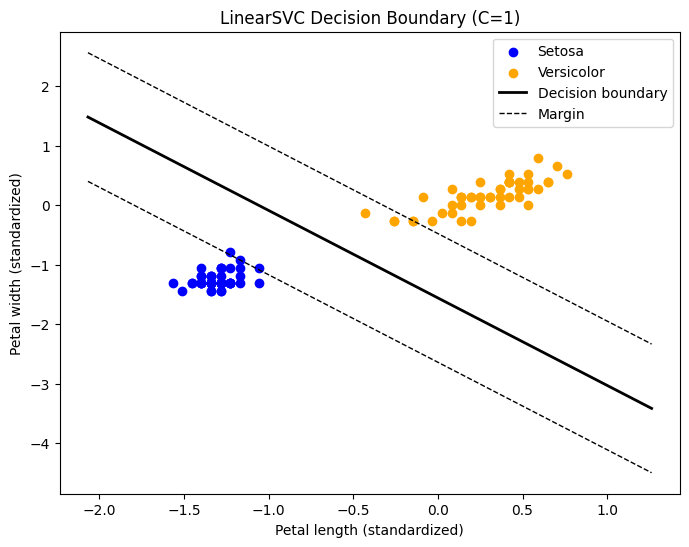

Test Accuracy (C=1): 1.0


In [20]:
### YOUR CODE STARTS HERE ###
# Train LinearSVC with C=1 and hinge loss
svm_clf = LinearSVC(C=1, loss="hinge", max_iter=10000, random_state=42)
svm_clf.fit(x_train, y_train)

# Decision boundary and margins: w0*x0 + w1*x1 + b = 0
w = svm_clf.coef_[0]
b = svm_clf.intercept_[0]

x0 = np.linspace(X_bin[:, 0].min() - 0.5, X_bin[:, 0].max() + 0.5, 200)
decision_boundary = -w[0] / w[1] * x0 - b / w[1]
margin = 1 / w[1]
gutter_up = decision_boundary + margin
gutter_down = decision_boundary - margin

plt.figure(figsize=(8, 6))
plt.scatter(X_bin[y_bin == 0, 0], X_bin[y_bin == 0, 1],
            color="blue", label="Setosa")
plt.scatter(X_bin[y_bin == 1, 0], X_bin[y_bin == 1, 1],
            color="orange", label="Versicolor")
plt.plot(x0, decision_boundary, "k-", linewidth=2, label="Decision boundary")
plt.plot(x0, gutter_up, "k--", linewidth=1, label="Margin")
plt.plot(x0, gutter_down, "k--", linewidth=1)
plt.xlabel("Petal length (standardized)")
plt.ylabel("Petal width (standardized)")
plt.title(f"LinearSVC Decision Boundary (C=1)")
plt.legend()
plt.show()

y_pred = svm_clf.predict(x_test)
test_accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Test Accuracy (C=1):", test_accuracy)
### YOUR CODE ENDS HERE ###

Q15: Train a linear support vector classifier (with C=1000 and hinge loss) on the training data. Plot the samples from the whole dataset, with decision boundary and margins (the two classes should have different colors). Predict on test set and print the resultant accuracy. [7 marks]

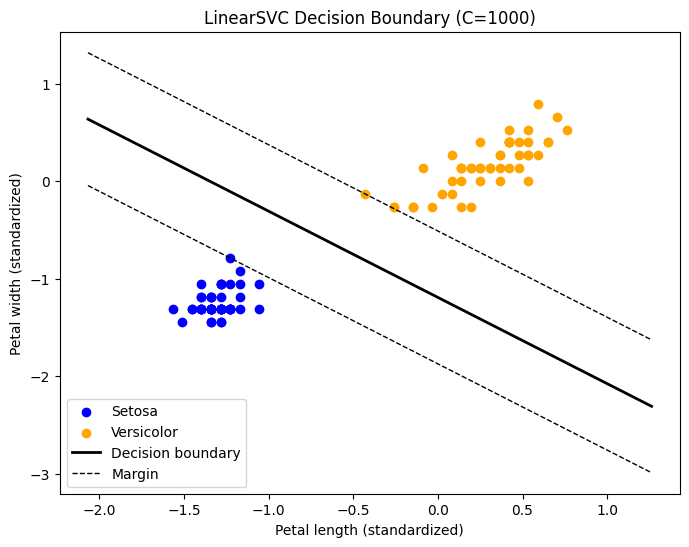

Test Accuracy (C=1000): 1.0


In [21]:
### YOUR CODE STARTS HERE ###
# Train LinearSVC with C=1000 and hinge loss
svm_clf = LinearSVC(C=1000, loss="hinge", max_iter=10000, random_state=42)
svm_clf.fit(x_train, y_train)

# Decision boundary and margins: w0*x0 + w1*x1 + b = 0
w = svm_clf.coef_[0]
b = svm_clf.intercept_[0]

x0 = np.linspace(X_bin[:, 0].min() - 0.5, X_bin[:, 0].max() + 0.5, 200)
decision_boundary = -w[0] / w[1] * x0 - b / w[1]
margin = 1 / w[1]
gutter_up = decision_boundary + margin
gutter_down = decision_boundary - margin

plt.figure(figsize=(8, 6))
plt.scatter(X_bin[y_bin == 0, 0], X_bin[y_bin == 0, 1],
            color="blue", label="Setosa")
plt.scatter(X_bin[y_bin == 1, 0], X_bin[y_bin == 1, 1],
            color="orange", label="Versicolor")
plt.plot(x0, decision_boundary, "k-", linewidth=2, label="Decision boundary")
plt.plot(x0, gutter_up, "k--", linewidth=1, label="Margin")
plt.plot(x0, gutter_down, "k--", linewidth=1)
plt.xlabel("Petal length (standardized)")
plt.ylabel("Petal width (standardized)")
plt.title(f"LinearSVC Decision Boundary (C=1000)")
plt.legend()
plt.show()

y_pred = svm_clf.predict(x_test)
test_accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Test Accuracy (C=1000):", test_accuracy)
### YOUR CODE ENDS HERE ###

# Part 4: Bagging [30 marks]

In [22]:
#imports
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

### Stage 1: Data Preparation for Bagging Implementation [5 marks]

In [23]:
# loading the dataset
def load_dataset():
  reg_x, reg_y = fetch_california_housing(return_X_y = True)

  reg_data = np.concatenate((reg_x, np.array(reg_y).reshape(-1, 1)), axis = 1)

  cols = ["feature"+str(i) for i in range(1, 9)]
  cols = cols + ["price(target)"]

  reg_dataset = pd.DataFrame(data = reg_data, columns = cols)

  return reg_dataset

reg_dataset = load_dataset()
print("REGRESSION DATASET : \n", reg_dataset)

REGRESSION DATASET : 
        feature1  feature2  feature3  feature4  feature5  feature6  feature7  \
0        8.3252      41.0  6.984127  1.023810     322.0  2.555556     37.88   
1        8.3014      21.0  6.238137  0.971880    2401.0  2.109842     37.86   
2        7.2574      52.0  8.288136  1.073446     496.0  2.802260     37.85   
3        5.6431      52.0  5.817352  1.073059     558.0  2.547945     37.85   
4        3.8462      52.0  6.281853  1.081081     565.0  2.181467     37.85   
...         ...       ...       ...       ...       ...       ...       ...   
20635    1.5603      25.0  5.045455  1.133333     845.0  2.560606     39.48   
20636    2.5568      18.0  6.114035  1.315789     356.0  3.122807     39.49   
20637    1.7000      17.0  5.205543  1.120092    1007.0  2.325635     39.43   
20638    1.8672      18.0  5.329513  1.171920     741.0  2.123209     39.43   
20639    2.3886      16.0  5.254717  1.162264    1387.0  2.616981     39.37   

       feature8  price(targe

Q16: Write a method to get the random indices from train set, and then use the random indices to create a variation of the training set, where some samples are randomly repeated while others are not included. Split the data into x (input) and y (target), each split into training and testing subsets, with 80% samples for training and 20% samples for testing. [5 marks]

In [24]:
### YOUR CODE STARTS HERE ###
def get_bootstrap_indices(n_samples):
    """Randomly draw n_samples indices with replacement."""
    return np.random.randint(0, n_samples, size=n_samples)

x = reg_dataset.drop("price(target)", axis=1).values
y = reg_dataset["price(target)"].values

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Example bootstrap resample of the training set
sample_indices = get_bootstrap_indices(len(x_train))
x_train_boot = x_train[sample_indices]
y_train_boot = y_train[sample_indices]

print("Original training set shape:", x_train.shape)
print("Bootstrap resampled training set shape:", x_train_boot.shape)
print("Test set shape:", x_test.shape)
### YOUR CODE ENDS HERE ###

Original training set shape: (16512, 8)
Bootstrap resampled training set shape: (16512, 8)
Test set shape: (4128, 8)


### Stage 2: Training of Linear Regression Models for Bagging Implementation [15 marks]

Q17: Train a linear regression model on the training set with random indices, and print the mean squared error of the predictions on the test set. [3 marks]

In [25]:
### YOUR CODE STARTS HERE ###
indices_1 = get_bootstrap_indices(len(x_train))
x_train_1 = x_train[indices_1]
y_train_1 = y_train[indices_1]

model_1 = LinearRegression()
model_1.fit(x_train_1, y_train_1)

pred_1 = model_1.predict(x_test)
mse_1 = mean_squared_error(y_test, pred_1)
print("MSE (Model 1):", mse_1)
### YOUR CODE ENDS HERE ###

MSE (Model 1): 0.5553648992660646


Q18: Fit a second linear regression model on a new variation of the training dataset with a new set of random indices, and print the mean squared error of the average of the predictions of the two linear regression models (this model and the model trianed in the previous question). [4 marks]

In [26]:
### YOUR CODE STARTS HERE ###
indices_2 = get_bootstrap_indices(len(x_train))
x_train_2 = x_train[indices_2]
y_train_2 = y_train[indices_2]

model_2 = LinearRegression()
model_2.fit(x_train_2, y_train_2)

pred_2 = model_2.predict(x_test)

avg_pred_2models = (pred_1 + pred_2) / 2
mse_2models = mean_squared_error(y_test, avg_pred_2models)
print("MSE (Average of 2 models):", mse_2models)
### YOUR CODE ENDS HERE ###

MSE (Average of 2 models): 0.5551355956696361


Q19: Fit a third linear regression model on a new variation of the training dataset with a new set of random indices, and print the mean squared error of the average of the predictions of the three linear regression models (this model and the model trianed in the previous two questions). [4 marks]

In [27]:
### YOUR CODE STARTS HERE ###
indices_3 = get_bootstrap_indices(len(x_train))
x_train_3 = x_train[indices_3]
y_train_3 = y_train[indices_3]

model_3 = LinearRegression()
model_3.fit(x_train_3, y_train_3)

pred_3 = model_3.predict(x_test)

avg_pred_3models = (pred_1 + pred_2 + pred_3) / 3
mse_3models = mean_squared_error(y_test, avg_pred_3models)
print("MSE (Average of 3 models):", mse_3models)
### YOUR CODE ENDS HERE ###

MSE (Average of 3 models): 0.5563529889751225


Q20: Fit a fourth linear regression model on a new variation of the training dataset with a new set of random indices, and print the mean squared error of the average of the predictions of the four linear regression models (this model and the model trianed in the previous three questions). [4 marks]

In [28]:
### YOUR CODE STARTS HERE ###
indices_4 = get_bootstrap_indices(len(x_train))
x_train_4 = x_train[indices_4]
y_train_4 = y_train[indices_4]

model_4 = LinearRegression()
model_4.fit(x_train_4, y_train_4)

pred_4 = model_4.predict(x_test)

avg_pred_4models = (pred_1 + pred_2 + pred_3 + pred_4) / 4
mse_4models = mean_squared_error(y_test, avg_pred_4models)
print("MSE (Average of 4 models):", mse_4models)
### YOUR CODE ENDS HERE ###

MSE (Average of 4 models): 0.5577399426022512


### Stage 3: Interative Variation in Bagging Implementation [10 marks]

Q21: Loop through using 2, 4, 6 ... 24 models and train the models with variations of the training dataset. Print the test mean squared error (take the average mean squared error of the corresponding 2, 4, 6 ... 24 models). Finally, plot the training loss and testing loss for all the cases (2, 4, 6 ... 24 models). [10 marks]

Number of models:  2 | Train MSE: 0.5185 | Test MSE: 0.5490
Number of models:  4 | Train MSE: 0.5180 | Test MSE: 0.5572
Number of models:  6 | Train MSE: 0.5185 | Test MSE: 0.5567
Number of models:  8 | Train MSE: 0.5197 | Test MSE: 0.5545
Number of models: 10 | Train MSE: 0.5870 | Test MSE: 0.5503
Number of models: 12 | Train MSE: 0.5179 | Test MSE: 0.5558
Number of models: 14 | Train MSE: 0.5180 | Test MSE: 0.5566
Number of models: 16 | Train MSE: 0.5366 | Test MSE: 0.5537
Number of models: 18 | Train MSE: 0.5190 | Test MSE: 0.5551
Number of models: 20 | Train MSE: 0.5353 | Test MSE: 0.5530
Number of models: 22 | Train MSE: 0.5293 | Test MSE: 0.5517
Number of models: 24 | Train MSE: 0.5182 | Test MSE: 0.5555


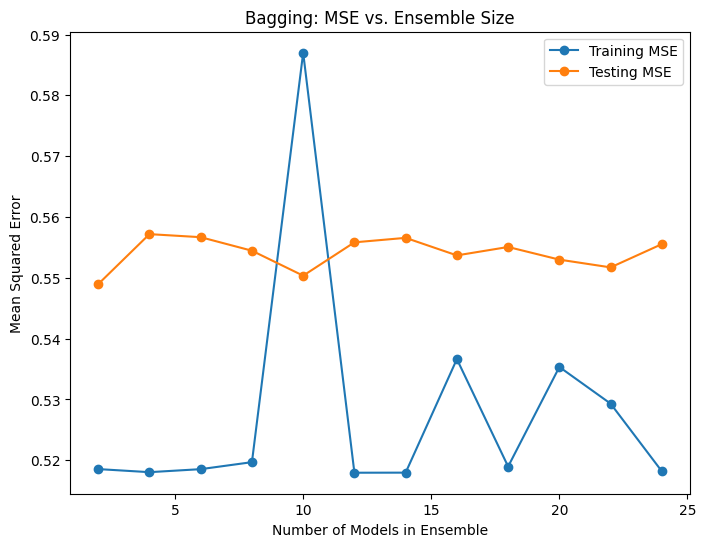

In [29]:
### YOUR CODE STARTS HERE ###
def bagging_experiment(n_models, x_train, y_train, x_test, y_test):
    train_preds = []
    test_preds = []
    for i in range(n_models):
        idx = get_bootstrap_indices(len(x_train))
        xb, yb = x_train[idx], y_train[idx]

        model = LinearRegression()
        model.fit(xb, yb)

        train_preds.append(model.predict(x_train))
        test_preds.append(model.predict(x_test))

    avg_train_pred = np.mean(train_preds, axis=0)
    avg_test_pred = np.mean(test_preds, axis=0)

    train_mse = mean_squared_error(y_train, avg_train_pred)
    test_mse = mean_squared_error(y_test, avg_test_pred)
    return train_mse, test_mse

ensemble_sizes = list(range(2, 25, 2))
train_mse_list = []
test_mse_list = []

for n_models in ensemble_sizes:
    train_mse, test_mse = bagging_experiment(n_models, x_train, y_train, x_test, y_test)
    train_mse_list.append(train_mse)
    test_mse_list.append(test_mse)
    print(f"Number of models: {n_models:2d} | Train MSE: {train_mse:.4f} | Test MSE: {test_mse:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(ensemble_sizes, train_mse_list, marker="o", label="Training MSE")
plt.plot(ensemble_sizes, test_mse_list, marker="o", label="Testing MSE")
plt.xlabel("Number of Models in Ensemble")
plt.ylabel("Mean Squared Error")
plt.title("Bagging: MSE vs. Ensemble Size")
plt.legend()
plt.show()
### YOUR CODE ENDS HERE ###

# Part 5: K-Means Clustering [30 marks]

In [30]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import random
import collections
from sklearn.datasets import load_iris
import pandas as pd

### Stage 1: Data Preparation and Method Definitions for K-Means Clustering Implementation [18 marks]

In [31]:
# loading the dataset and creating the points
iris = load_iris(as_frame=True)
df = iris.frame

data = df[['petal length (cm)', 'petal width (cm)']]

data.head()

points=data.values.tolist()
points=np.array(points)

Q22: Write a method that takes a data point and a list of centroids, calculates the Euclidean distance between the point and each centroid, and returns the index of the closest centroid. [3 marks]

In [32]:
### YOUR CODE STARTS HERE ###
def closest_centroid(point, centroids):
    distances = [np.sqrt(np.sum((point - centroid) ** 2)) for centroid in centroids]
    return int(np.argmin(distances))
### YOUR CODE ENDS HERE ###

Q23: Write a method that takes a dictionary mapping cluster IDs to lists of 2D data points, calculates the new centroid for each cluster by averaging its points, and returns the updated centroids as a NumPy array. [3 marks]

In [33]:
### YOUR CODE STARTS HERE ###
def compute_new_centroids(clusters):
    new_centroids = []
    for cluster_id in sorted(clusters.keys()):
        cluster_points = np.array(clusters[cluster_id])
        new_centroids.append(cluster_points.mean(axis=0))
    return np.array(new_centroids)
### YOUR CODE ENDS HERE ###

Q24: Write a method that takes a random seed and an integer "p", sets the seed for reproducibility, and randomly selects "p" initial centroids from a globally defined points dataset, returning them as a NumPy array. [3 marks]

In [34]:
### YOUR CODE STARTS HERE ###
def initialize_centroids(seed, p):
    np.random.seed(seed)
    indices = np.random.choice(len(points), size=p, replace=False)
    return points[indices]
### YOUR CODE ENDS HERE ###

Q25: Write a method that calculates the Sum of Squared Errors (SSE) for a clustering model. The function should take an array of centroids, a dictionary mapping cluster indices to lists of data points, and the total number of clusters "k", and return the sum of the squared Euclidean distances between every point and its assigned centroid. [3 marks]

In [35]:
### YOUR CODE STARTS HERE ###
def compute_sse(centroids, clusters, k):
    sse = 0.0
    for cluster_id in range(k):
        cluster_points = np.array(clusters[cluster_id])
        centroid = centroids[cluster_id]
        sse += np.sum((cluster_points - centroid) ** 2)
    return sse

### YOUR CODE ENDS HERE ###

Q26: Write a method that implements the main K-means clustering loop. The function should take the number of clusters "p", a list of data points, and an array of initial centroids seed. It must iteratively assign each point to its nearest centroid, compute the new centroids, and repeat this process until convergence (when the centroids no longer change), ultimately returning the final centroids and a dictionary of the cluster assignments. Whenever kmeans needs to be implemented for any of the following questions, this kmeans implementation from scratch should be used. [6 marks]

In [36]:
### YOUR CODE STARTS HERE ###
def kmeans(p, data, initial_centroids):
    centroids = np.array(initial_centroids, dtype=float)
    data = np.array(data)

    while True:
        # Assignment step
        clusters = {i: [] for i in range(p)}
        for point in data:
            idx = closest_centroid(point, centroids)
            clusters[idx].append(point)

        # Guard against empty clusters
        for i in range(p):
            if len(clusters[i]) == 0:
                clusters[i].append(centroids[i])

        # Update step
        new_centroids = compute_new_centroids(clusters)

        # Convergence check
        if np.allclose(new_centroids, centroids):
            centroids = new_centroids
            break

        centroids = new_centroids

    return centroids, clusters
### YOUR CODE ENDS HERE ###

### Stage 2: Finding the Centroids using K-Means Clustering Implementation [12 marks]

Q27: Write a Python script that iterates over cluster counts from 1 to 4, executes the K-means algorithm using a fixed random seed of 42 for initialization, computes the Sum of Squared Errors (SSE) for each configuration, and returns the list of SSE values. Then plot the sum of squared distance in the y-axis and number of clusters in the x-axis. [6 marks]

k = 1: SSE = 550.8953
k = 2: SSE = 86.3902
k = 3: SSE = 31.4129
k = 4: SSE = 20.3358


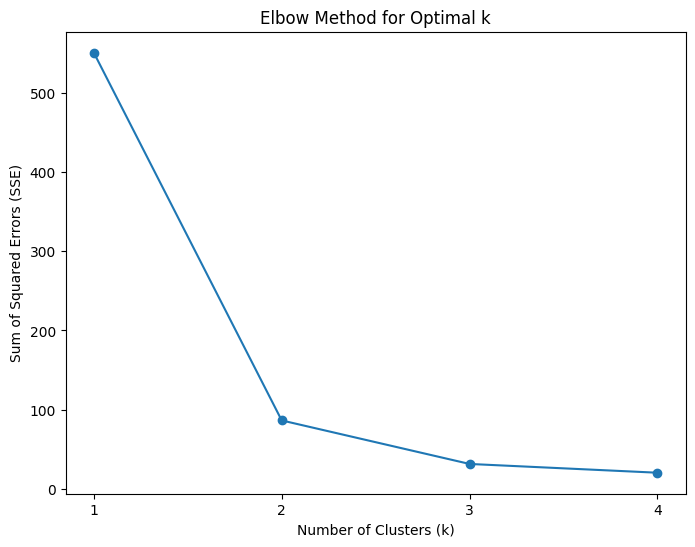

In [37]:
### YOUR CODE STARTS HERE ###
sse_values = []
k_values = range(1, 5)

for k in k_values:
    initial_centroids = initialize_centroids(seed=42, p=k)
    centroids, clusters = kmeans(k, points, initial_centroids)
    sse = compute_sse(centroids, clusters, k)
    sse_values.append(sse)
    print(f"k = {k}: SSE = {sse:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(list(k_values), sse_values, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.title("Elbow Method for Optimal k")
plt.xticks(list(k_values))
plt.show()

### YOUR CODE ENDS HERE ###

Q28: Use the best number of clusters from elbow method, and visualize the data after applying kmeans on the data using a 2D scatter plot. The two classes should be differently colored, and the centroids should also be shown. [6 marks]

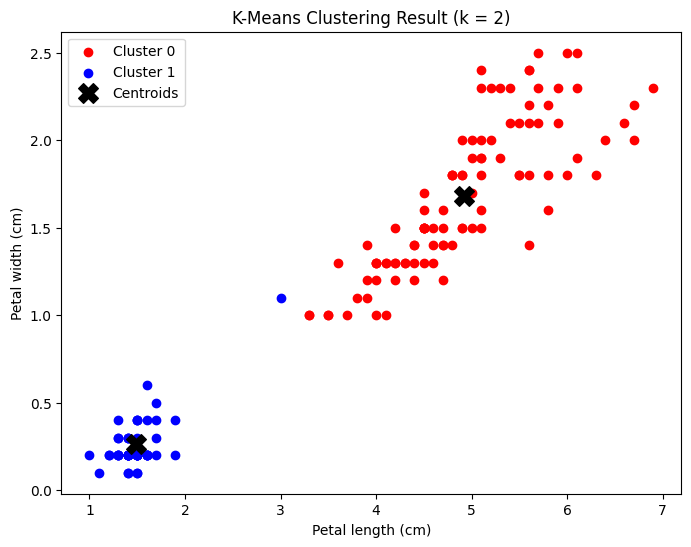

In [38]:
### YOUR CODE STARTS HERE ###
best_k = 2  # chosen based on the "elbow" observed in the SSE plot above

initial_centroids = initialize_centroids(seed=42, p=best_k)
final_centroids, final_clusters = kmeans(best_k, points, initial_centroids)

colors = ["red", "blue", "green", "purple"]

plt.figure(figsize=(8, 6))
for cluster_id in range(best_k):
    cluster_points = np.array(final_clusters[cluster_id])
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                color=colors[cluster_id % len(colors)],
                label=f"Cluster {cluster_id}")

plt.scatter(final_centroids[:, 0], final_centroids[:, 1],
            color="black", marker="X", s=200, label="Centroids")

plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title(f"K-Means Clustering Result (k = {best_k})")
plt.legend()
plt.show()

### YOUR CODE ENDS HERE ###